In [17]:
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import glob
from tqdm import tqdm

In [23]:
TRAIN_DATA_DIR = "/pscratch/sd/r/rmastand/particlemind/data/p8_ee_tt_ecm365_parquetfiles_train"

files = sorted(glob.glob(f"{TRAIN_DATA_DIR}/*.parquet"))

print(f"Found {len(files)} parquet files")

len_events_train = []

for f in tqdm(files):
    data = ak.from_parquet(f)["calo_hit_features"]["position.x"]
    len_events_train += [len(event) for event in data]



TEST_DATA_DIR = "/pscratch/sd/r/rmastand/particlemind/data/p8_ee_tt_ecm365_parquetfiles_test"

files = sorted(glob.glob(f"{TEST_DATA_DIR}/*.parquet"))

print(f"Found {len(files)} parquet files")

len_events_test = []

for f in tqdm(files):
    data = ak.from_parquet(f)["calo_hit_features"]["position.x"]
    len_events_test += [len(event) for event in data]



Found 450 parquet files


100%|██████████| 450/450 [01:36<00:00,  4.67it/s]


Found 50 parquet files


100%|██████████| 50/50 [00:12<00:00,  3.86it/s]


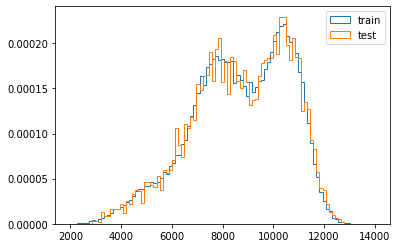

2093 2911
13399 12704


In [26]:
plt.figure()
plt.hist(len_events_train, bins = np.linspace(2000, 14000, 100), histtype = "step", label = "train", density = True)
plt.hist(len_events_test, bins = np.linspace(2000, 14000, 100), histtype = "step", label = "test", density = True)
plt.legend()
plt.show()

print(min(len_events_train), min(len_events_test))
print(max(len_events_train), max(len_events_test))

In [30]:
batch_size = 2
train_fraction = 0.8
num_train_files = 450
num_train_events = int(train_fraction*num_train_files*100)
num_val_events = num_train_files*100 - num_train_events

print(f"Num train events: {num_train_events}")
print(f"Num val events: {num_val_events}")

print(f"Num train batches: {num_train_events//batch_size}")
print(f"Num val batches: {num_val_events//batch_size}")

Num train events: 36000
Num val events: 9000
Num train batches: 18000
Num val batches: 4500
